# 20. How the self-similar exponents $\alpha,\beta$ shape the tSZ power spectrum

Fix the GNFW pressure **shape** to hmfast's Arnaud et al. (2010) defaults
(`GNFWPressureProfile`: $P_0,c_{500},\alpha_\mathrm{GNFW},\beta_\mathrm{GNFW},\gamma$)
and vary only the **self-similar amplitude exponents** in

$$P_{500}=P_{500,0}\,(M_{500c}/M_\odot)^{\alpha}\,E(z)^{2+\beta},$$

where $\alpha$ is the mass slope and $\beta$ the $E(z)$ slope (nb17 convention;
self-similar $\alpha=\beta=2/3$). We plot the raw halo-model tSZ $D_\ell$;
$P_{500,0}$ is set by `SelfSimilarGNFWPressureProfile.from_arnaud_pivot` so that
$P_{500}(M_\mathrm{piv},z{=}0)$ matches the Arnaud (2010) $P_{500c}$ normalization
(hmfast eq. 2) at each $\alpha$.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import sys
sys.path.insert(0, "/scratch/scratch-lxu/flamingo_repo/src")

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from flamingo.catalogue import D3A_COSMOLOGY
from flamingo.profiles.custom_pressure import SelfSimilarGNFWPressureProfile
from hmfast.halos import HaloModel
from hmfast.halos.profiles import GNFWPressureProfile
from hmfast.tracers import tSZTracer

M_PIV = 6.0e14
Z_PIV = 0.0
B = 1.0
A10_SHAPE = dict(P0=8.130, c500=1.156, alpha=1.0620, beta=5.4807, gamma=0.3292, B=B)

hm = HaloModel(cosmology=D3A_COSMOLOGY)
ell = jnp.logspace(1.3, np.log10(6000), 40)
m_grid = jnp.logspace(11.0, 15.5, 50)
z_grid = jnp.geomspace(0.01, 3.0, 50)
pref = np.asarray(ell) * (np.asarray(ell) + 1) / (2 * np.pi)
ell_np = np.asarray(ell)


def tsz_dl(alpha_amp, beta_amp):
    """Halo-model tSZ D_ell; P500_0 from Arnaud (2010) P500c at (M_piv, z_piv)."""
    prof = SelfSimilarGNFWPressureProfile.from_arnaud_pivot(
        D3A_COSMOLOGY, M_piv=M_PIV, z_piv=Z_PIV,
        alpha_amp=alpha_amp, beta_amp=beta_amp, **A10_SHAPE,
    )
    tr = tSZTracer(profile=prof)
    cl = np.asarray(hm.cl_1h(tr, tr, l=ell, m=m_grid, z=z_grid)) \
       + np.asarray(hm.cl_2h(tr, tr, l=ell, m=m_grid, z=z_grid))
    return pref * cl


tr_a10 = tSZTracer(profile=GNFWPressureProfile(**A10_SHAPE))
dl_a10 = pref * (
    np.asarray(hm.cl_1h(tr_a10, tr_a10, l=ell, m=m_grid, z=z_grid))
    + np.asarray(hm.cl_2h(tr_a10, tr_a10, l=ell, m=m_grid, z=z_grid))
)
print(f"D_ell(l=3000) hmfast GNFW A10 B=1: {np.interp(3000, ell_np, dl_a10):.3e}")


D_ell(l=3000) hmfast GNFW A10 B=1: 1.801e-12


In [2]:
ALPHAS = [0.40, 0.67, 1.00, 1.33, 1.67]   # mass slope (beta fixed)
BETAS = [-0.67, 0.00, 0.67, 1.33, 2.00]    # E(z) slope (alpha fixed)
BETA_FIX, ALPHA_FIX = 2.0 / 3.0, 2.0 / 3.0

dl_alpha = {a: tsz_dl(a, BETA_FIX) for a in ALPHAS}
dl_beta = {b: tsz_dl(ALPHA_FIX, b) for b in BETAS}

def _p500_0(a, b):
    return SelfSimilarGNFWPressureProfile.from_arnaud_pivot(
        D3A_COSMOLOGY, M_piv=M_PIV, z_piv=Z_PIV, alpha_amp=a, beta_amp=b, **A10_SHAPE
    ).P500_0

print("P500_0 vs alpha:", {a: f"{_p500_0(a, BETA_FIX):.3e}" for a in ALPHAS})
print("peak ell vs alpha:", {a: int(ell_np[np.argmax(d)]) for a, d in dl_alpha.items()})
print("peak ell vs beta :", {b: int(ell_np[np.argmax(d)]) for b, d in dl_beta.items()})
dl_ss = tsz_dl(ALPHA_FIX, BETA_FIX)
print("D_ell(l=3000) alpha=beta=2/3:", float(np.interp(3000, ell_np, dl_ss)))


P500_0 vs alpha: {0.4: '3.370e-06', 0.67: '3.448e-10', 1.0: '4.579e-15', 1.33: '6.081e-20', 1.67: '5.747e-25'}
peak ell vs alpha: {0.4: 5999, 0.67: 4477, 1.0: 2494, 1.33: 1607, 1.67: 1200}
peak ell vs beta : {-0.67: 2494, 0.0: 2886, 0.67: 4477, 1.33: 5999, 2.0: 5999}
D_ell(l=3000) alpha=beta=2/3: 2.331104199994321e-12


<>:23: SyntaxWarning: invalid escape sequence '\e'
<>:23: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2554979/3691109387.py:23: SyntaxWarning: invalid escape sequence '\e'
  fig.suptitle("tSZ $D_\ell$ vs self-similar amplitude exponents "


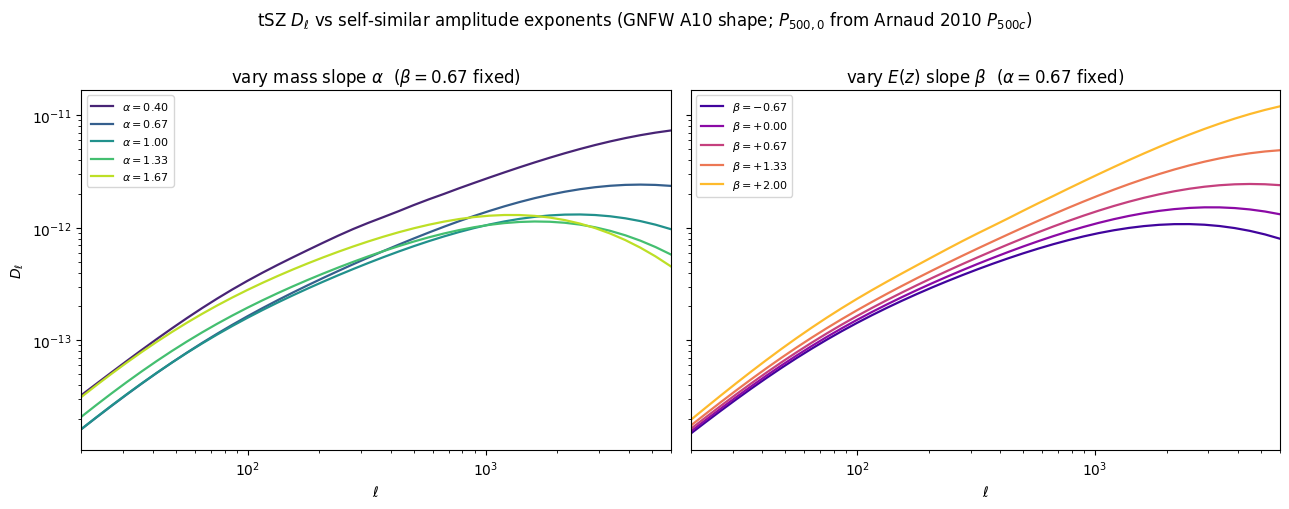

In [3]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

cA = plt.cm.viridis(np.linspace(0.1, 0.9, len(ALPHAS)))
for col, a in zip(cA, ALPHAS):
    lw = 2.6 if abs(a - 2/3) < 1e-6 else 1.6
    axA.plot(ell_np, dl_alpha[a], color=col, lw=lw,
             label=fr"$\alpha={a:.2f}$" + (" (self-sim.)" if abs(a-2/3) < 1e-6 else ""))
axA.set_title(fr"vary mass slope $\alpha$  ($\beta={BETA_FIX:.2f}$ fixed)")
axA.set_xlabel(r"$\ell$"); axA.set_ylabel(r"$D_\ell$")

cB = plt.cm.plasma(np.linspace(0.1, 0.85, len(BETAS)))
for col, b in zip(cB, BETAS):
    lw = 2.6 if abs(b - 2/3) < 1e-6 else 1.6
    axB.plot(ell_np, dl_beta[b], color=col, lw=lw,
             label=fr"$\beta={b:+.2f}$" + (" (self-sim.)" if abs(b-2/3) < 1e-6 else ""))
axB.set_title(fr"vary $E(z)$ slope $\beta$  ($\alpha={ALPHA_FIX:.2f}$ fixed)")
axB.set_xlabel(r"$\ell$")

for ax in (axA, axB):
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(ell_np.min(), ell_np.max())
    ax.legend(fontsize=8)
fig.suptitle("tSZ $D_\ell$ vs self-similar amplitude exponents "
             "(GNFW A10 shape; $P_{500,0}$ from Arnaud 2010 $P_{500c}$)", y=1.01)
fig.tight_layout(); plt.show()


### Trends

- **Mass slope $\alpha$** (left): increasing $\alpha$ up-weights the most massive
  halos, which subtend large angles, so power moves to **lower $\ell$** — the spectrum
  reddens and the peak shifts down. $P_{500,0}$ is recalibrated at each $\alpha$ via
  `from_arnaud_pivot` so $P_{500}(M_\mathrm{piv},z{=}0)$ stays on the Arnaud (2010)
  $P_{500c}$ relation.
- **$E(z)$ slope $\beta$** (right): increasing $\beta$ up-weights **high redshift**
  (where $E(z)$ is large), and high-$z$ clusters subtend smaller angles, so power moves
  to **higher $\ell$** — the peak shifts up. At $z=0$ the Arnaud pivot fix does not
  depend on $\beta$, so all $\beta$ curves share the same $P_{500,0}$.
- The hmfast `GNFWPressureProfile` reference ($D_\ell$ printed above) uses the same
  Arnaud $P_{500c}$ at every $(M,z)$; the self-similar exponents here only match it at
  the pivot unless $\alpha=2/3+0.12$ and $\beta=2/3$.